## Import Libraries

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import scipy
from scipy.interpolate import griddata
import torch
import bfieldtools
from bfieldtools.utils import load_example_mesh,combine_meshes
import bfieldtools.mesh_magnetics
import trimesh
import os
mu_0=scipy.constants.mu_0
pi=scipy.constants.pi

## Load Data and change units

Standard Path Chiara: ```Y:\MSR\Mapper\Mapper_Scan_MeasureV2\ParameterRuns\2026-03-16_09-37-30_degaussing_runs_parameter\2026-03-16_09-47-12_C3\maps\map\map\map_meta.npz```

In [ ]:
# path_npz=r"P:\MSR\Mapper\Mapper_Scan_MeasureV2\ParameterRuns\2026-03-16_09-37-30_degaussing_runs_parameter\2026-03-16_09-47-12_C3\maps\map\map\map_meta.npz"
path_npz=r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\after_degauss_with_current_2026-04-27_16-54-25\map\map_meta.npz"
data = np.load(path_npz)            # data is a map which has the attributes data.files


# This Block is for use of "Example_map" or "Improved_map"
# print(data.files)                   # list of arrays stored in the archive
# print(data['start_offset_mm'],data['origin_assumed_mm'],data['Lx'],data['Lz'])
# shift_x=data['Lx']/2*1e-3
# shift_y=data['Ly']/2*1e-3
# shift_z=data['Lz']/2*1e-3

L_x = 0.800
L_y = 0.800
L_z = 0.400
step_size = 0.200

shift_x = 0
shift_y = 0
shift_z = 0

In [36]:
# folder_path = r"P:\MSR\Mapper\Mapper_Scan_MeasureV2\ParameterRuns\2026-03-16_09-37-30_degaussing_runs_parameter\2026-03-16_09-47-12_C3\maps\map\map\points"
folder_path = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\after_degauss_with_current_2026-04-27_16-54-25\map\points"
all_target_points = []
all_B_targets = []

for filename in os.listdir(folder_path):                    # iterates through all pts. in npz directory
    if filename.endswith(".npz"):
        file_path = os.path.join(folder_path, filename)
        data = np.load(file_path)
        #print(f"{filename}: {data.files}")

        x = data['x_mm'] * 1e-3-shift_x                     # Umrechnung in [m] und Versetzen des Nullpunkts
        y = data['y_mm'] * 1e-3-shift_y
        z = data['z_mm'] * 1e-3-shift_z
        mean_Bx = data['mean_Bx_pT'] * 1e-12                # Umrechnen in [T]
        mean_By = data['mean_By_pT'] * 1e-12
        mean_Bz = data['mean_Bz_pT'] * 1e-12

        each_target_point = np.array([x, y, z]).T   # (Npoints, 3)
        each_B_target = np.array([mean_Bx, mean_By, mean_Bz]).T  # (Npoints, 3)

        all_target_points.append(each_target_point)
        all_B_targets.append(each_B_target)

# Stack all files into final (total_Npoints, 3) arrays
target_points = np.vstack(all_target_points)  # (total_Npoints, 3)
B_targets = np.vstack(all_B_targets)          # (total_Npoints, 3)

print(target_points.shape)  # e.g. (5000, 3)
print(B_targets.shape)      # e.g. (5000, 3)

(75, 3)
(75, 3)


## Alternative Map

**Interpolates** and creates *more* points!!

Don`t execute this for fast computation!!!

Von Chiara (Mo 20 04 2026)

In [9]:
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from scipy.interpolate import RBFInterpolator

# New z levels to interpolate at (stay within your data's z range)
z_min, z_max = target_points[:, 2].min(), target_points[:, 2].max()
new_z_levels = np.linspace(z_min, z_max, 5)  # 20 planes, tune as needed

# Build interpolators from ALL data using (x, y, z) → Bx, By, Bz
coords_3d = target_points  # (N, 3)

interp_Bx = RBFInterpolator(coords_3d, B_targets[:, 0])
interp_By = RBFInterpolator(coords_3d, B_targets[:, 1])
interp_Bz = RBFInterpolator(coords_3d, B_targets[:, 2])

# For each new z, create a grid in x,y within existing data extent
x_min, x_max = target_points[:, 0].min(), target_points[:, 0].max()
y_min, y_max = target_points[:, 1].min(), target_points[:, 1].max()
n_xy = 5  # resolution of each new plane, tune as needed

all_new_points = []
all_new_B = []

for z_val in new_z_levels:
    xs = np.linspace(x_min, x_max, n_xy)
    ys = np.linspace(y_min, y_max, n_xy)
    xx, yy = np.meshgrid(xs, ys)
    zz = np.full_like(xx, z_val)
    
    grid = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()])  # (n_xy^2, 3)
    
    Bx = interp_Bx(grid)
    By = interp_By(grid)
    Bz = interp_Bz(grid)
    
    # Drop points where interpolation failed (outside convex hull of original data)
    valid = ~np.isnan(Bx)

    all_new_points.append(grid[valid])
    all_new_B.append(np.column_stack([Bx[valid], By[valid], Bz[valid]]))
    
target_points = np.vstack(all_new_points)
B_targets = np.vstack(all_new_B)

print(f"Total: {len(target_points)} → {len(target_points)} points")

Total: 125 → 125 points


## Plot extracted Data

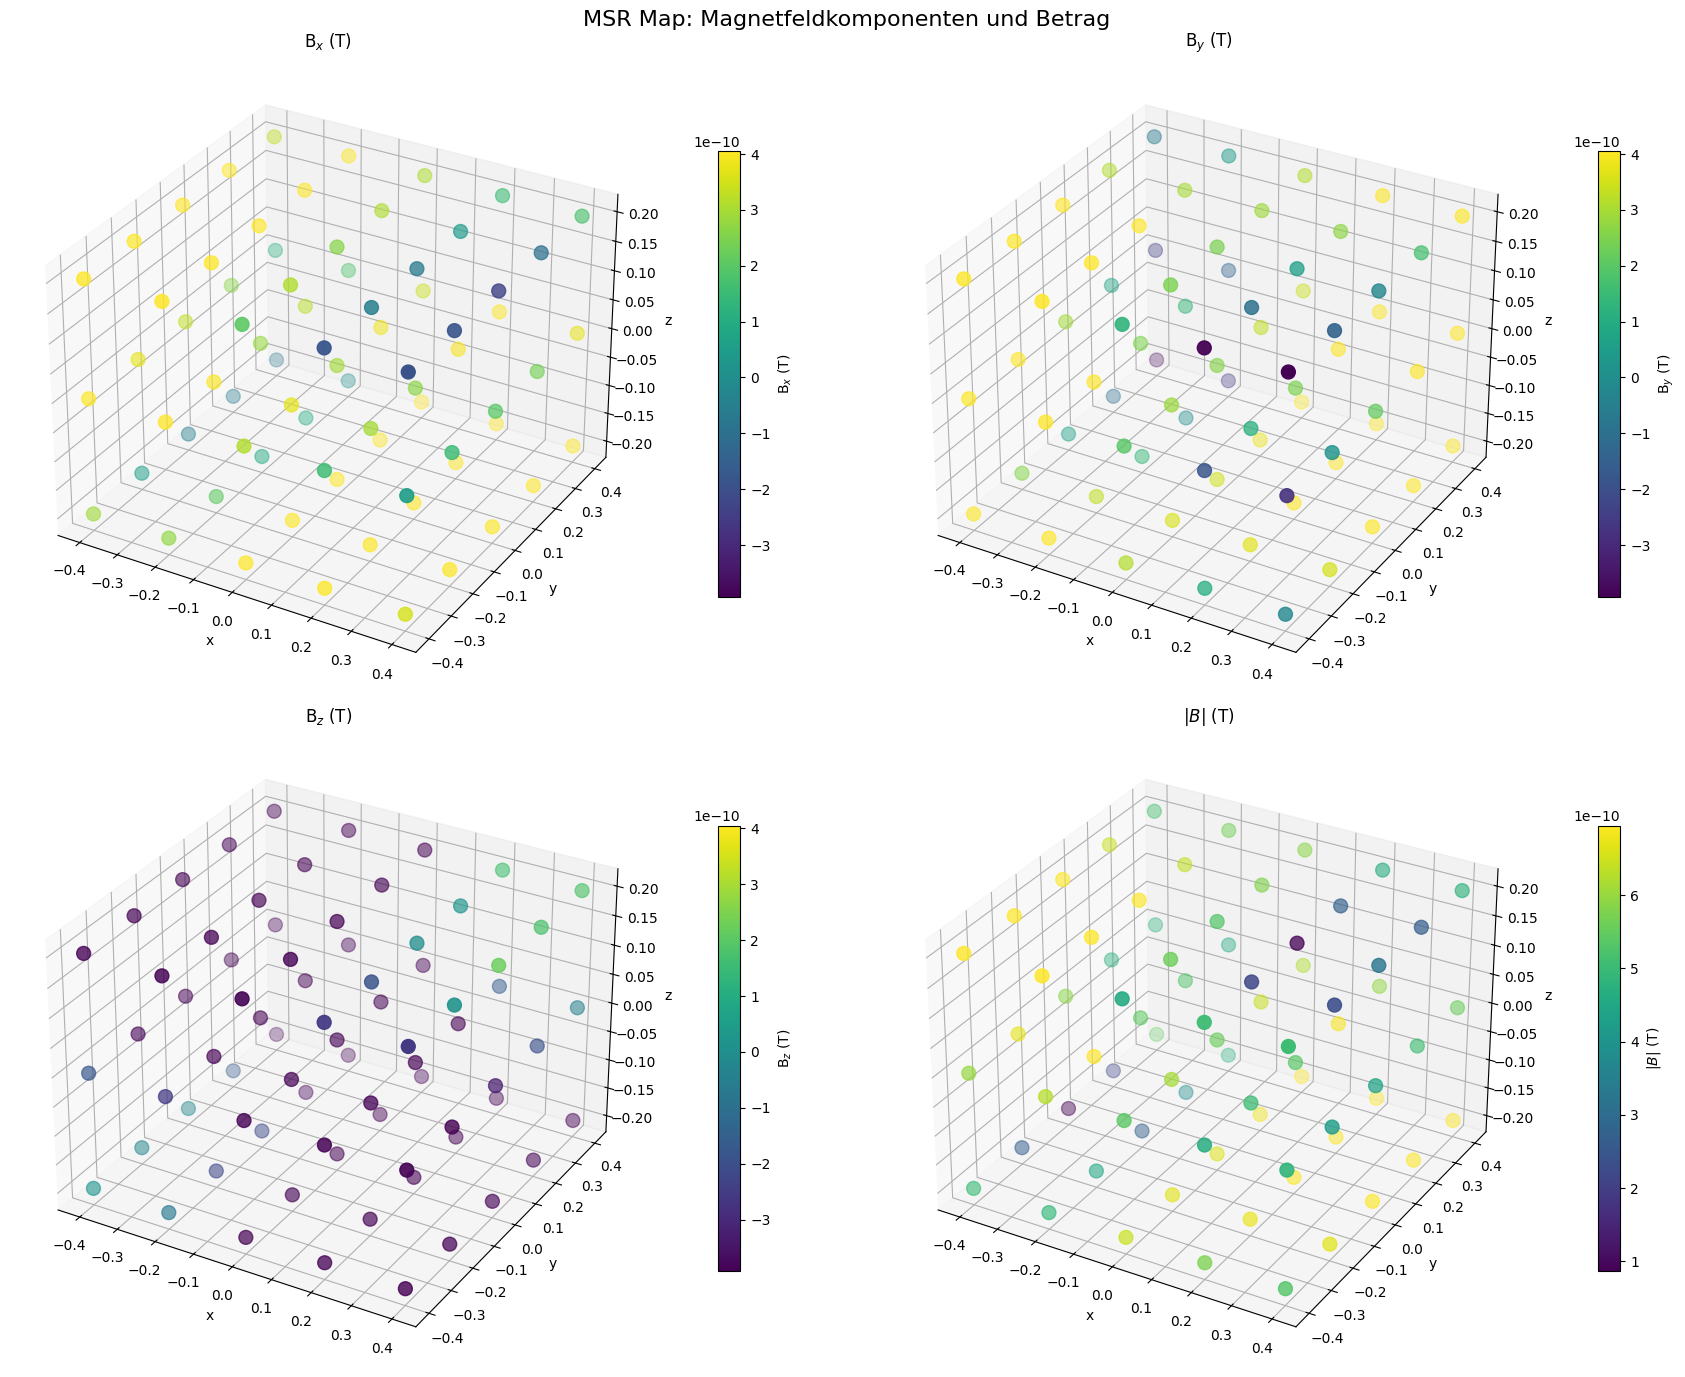

In [37]:
x = target_points[:, 0]
y = target_points[:, 1]
z = target_points[:, 2]

Bx = B_targets[:, 0]
By = B_targets[:, 1]
Bz = B_targets[:, 2]
Bnorm = np.linalg.norm(B_targets, axis=1)

fig = plt.figure(figsize=(18, 14))

axs = [
    fig.add_subplot(2, 2, 1, projection='3d'),
    fig.add_subplot(2, 2, 2, projection='3d'),
    fig.add_subplot(2, 2, 3, projection='3d'),
    fig.add_subplot(2, 2, 4, projection='3d')
]

component_data = [Bx, By, Bz]
vmin_comp = min(d.min() for d in component_data)
vmax_comp = max(d.max() for d in component_data)

plots = [
    (Bx, 'B$_x$ (T)', vmin_comp, vmax_comp),
    (By, 'B$_y$ (T)', vmin_comp, vmax_comp),
    (Bz, 'B$_z$ (T)', vmin_comp, vmax_comp),
    (Bnorm, r'$|B|$ (T)', Bnorm.min(), Bnorm.max())
]

for ax, (vals, title, vmin, vmax) in zip(axs, plots):
    sc = ax.scatter(x, y, z, c=vals, s=100, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.08, label=title)

fig.suptitle('MSR Map: Magnetfeldkomponenten und Betrag', fontsize=16)
plt.tight_layout()
plt.show()

In [30]:
print(data['x_mm'],data['y_mm'],data['z_mm'],data['mean_Bx_pT'])

400.0 400.0 200.0 -150.07321484438577


## Geometric Data MSR

In [ ]:
shield = 2.3            # [m] (MSR dimensions - cubic)
coil_plane = 2        # [m] (size of coil plane, smaller than MSR to avoid edge effects)
door_width = 0.95       # [m] (width of the door)
door_height = 2.004     # [m] (height of the door)
door_offset_x = 0.2375  # [m] (distance from door frame to right wall)
door_floor_offset = 0.0 # [m] (distance from door frame to floor)
coil_loc = coil_plane / 2 + 0.1# [m] (distance of coil plane from center, must be smaller or equal to coil_plane/2)

# Size inner "wood-cube"
height_inner_wood = 2.20
width_inner_wood, depth_inner_wood = 2.34, 2.34

## Create Mesh
 - first create a square mesh in all 3 planes (xy, xz, yz) by defining np.arrays with the vertices (Coordinates in 3D)
 - create triangles with same indizes as square grid
 - overlay triangles onto square grid (index -> actual coordinates) and subdivide to refine
 - convert the triangle mesh to a ```Trimesh``` such the library can use it
 - Add the third coordinate by introducing a distance of the planes to the origin (direction normal to plane)
 

 

In [ ]:
# Create eqidistant spacing in each direction as basis for the grid
nx,ny,nz=10,10,10
size=coil_plane / 2                                                    # Size of the grid in each direction (Note: coil_loc = 0.9)
x=np.linspace(-size,size,nx)
y=np.linspace(-size,size,ny)
z=np.linspace(-size,size,nz)

#xy-plane = bottom, top -> stores points (vertices) of 2D square grid
xx,yy=np.meshgrid(x,y)                                                  # xx is an array of ny copies of x (yy analogue)
xy_plane=np.column_stack([xx.ravel(),yy.ravel(),np.zeros(xx.size)])     # .ravel flattens the array to 1D and .column_stack puts arrays onto each other, s.t. the points (vertices) of the 2D grid are stored with a 0 attended to each point.

#xz-plane=(front not anymore),back
xx,zz=np.meshgrid(x,z)
xz_plane=np.column_stack([xx.ravel(),np.zeros(xx.size),zz.ravel()])

#yz-plane=left, right
yy,zz=np.meshgrid(y,z)
yz_plane=np.column_stack([np.zeros(yy.size),yy.ravel(),zz.ravel()])

triangles_xy=[]


for i in range(ny - 1):
    for j in range(nx - 1):
        p0 = i * nx + j # point on grid (nx by ny)
        p1 = p0 + 1     # next point to the right of p0
        p2 = p0 + nx    # next point above p0
        p3 = p2 + 1     # next point to the right of p2

        # triangle 1
        triangles_xy.append([p0, p1, p2])
        # triangle 2
        triangles_xy.append([p1, p3, p2])

triangles_xy = np.array(triangles_xy)
triangles_xz=triangles_xy.copy()
triangles_yz=triangles_xy.copy()
tri_xy=trimesh.Trimesh(xy_plane,triangles_xy)
tri_xz=trimesh.Trimesh(xz_plane,triangles_xz)
tri_yz=trimesh.Trimesh(yz_plane,triangles_yz)
tri_xy=tri_xy.subdivide().subdivide()#.subdivide()
tri_xz=tri_xz.subdivide().subdivide()#.subdivide()
tri_yz=tri_yz.subdivide().subdivide()#.subdivide()

x = tri_xz.vertices[:, 0]
z = tri_xz.vertices[:, 2]
faces = tri_xz.faces
import matplotlib.tri as mtri
# Create triangulation object
triang = mtri.Triangulation(x, z, faces)

# Plot the mesh in 2D
fig, ax = plt.subplots(figsize=(6,6))
ax.triplot(triang, color='k', linewidth=0.8)

# coil_loc = distance to origin! -> Distance to wall = 1/2 room_length - coil_loc -> already defined in dimensions
plus_off_xy=np.array([0,0,coil_loc])
minus_off_xy=np.array([0,0,-coil_loc])
plus_off_xz=np.array([0,coil_loc,0])
minus_off_xz=np.array([0,-coil_loc,0])
plus_off_yz=np.array([coil_loc,0,0])
minus_off_yz=np.array([-coil_loc,0,0])

coil_plus_xy=trimesh.Trimesh(
    tri_xy.vertices+plus_off_xy,tri_xy.faces,process=False
)
coil_minus_xy=trimesh.Trimesh(
    tri_xy.vertices+minus_off_xy,tri_xy.faces,process=False
)
coil_plus_xz=trimesh.Trimesh(
    tri_xz.vertices+plus_off_xz,tri_xz.faces,process=False
)
coil_minus_xz=trimesh.Trimesh(
    tri_xz.vertices+minus_off_xz,tri_xz.faces,process=False
)
coil_plus_yz=trimesh.Trimesh(
    tri_yz.vertices+plus_off_yz,tri_yz.faces,process=False
)
coil_minus_yz=trimesh.Trimesh(
    tri_yz.vertices+minus_off_yz,tri_yz.faces,process=False
)

## Remove Door

- Introduce position of the Door
- Iterate through all faces and assign all faces to either wall _or_ door _or_ non of them using the geometry. (Loop)
- Remove vertices (edge-points of each face) which do not have any more faces (both door & wall).
- Remap face indices to new vertex array (both door & wall).
- Create a new, clean mesh of the wall together with the door
- combine everything into one variable ```total plane``` which can be read by the libraries
- print for debugging (inbetween print the length of the face array)
- __Note: Only run this block once. If it should be executed again, first execute the previouse block!__

In [ ]:
# Include door in xz-plane (front wall) -> remove by using .difference() which is a boolean operation substracting the door mesh from the rest
door_xmin = shield/2 - door_offset_x - door_width
door_xmax = shield/2 - door_offset_x
door_zmin = -shield/2 + door_floor_offset
door_zmax = -shield/2 + door_floor_offset + door_height

door_faces = []
front_wall_faces = []

print(f"Before loop: door_faces len={len(door_faces)}, front_wall_faces len={len(front_wall_faces)}")

for fi, face in enumerate(coil_plus_xz.faces):
    v0, v1, v2 = face                                           # Assign each corner of the triangle to a vertex index
    xpts = [x[v0], x[v1], x[v2]]                                # Get the x-coordinates of the triangle vertices
    zpts = [z[v0], z[v1], z[v2]]                                # Get the z-coordinates of the triangle vertices
    
    # All 3 vertices inside door rectangle?
    if (all(door_xmin <= px <= door_xmax for px in xpts) and    # Check door
        all(door_zmin <= pz <= door_zmax for pz in zpts)):
        door_faces.append(face)
    elif (all(door_xmin >= px or px >= door_xmax for px in xpts) or    # Check front wall
          all(door_zmin >= pz or pz >= door_zmax for pz in zpts)):
        front_wall_faces.append(face)

# Remaining faces form wall with hole
door_faces = np.array(door_faces)
front_wall_faces = np.array(front_wall_faces)

print(f"After loop: door_faces len={len(door_faces)}, front_wall_faces len={len(front_wall_faces)}")
print(f"Total faces: {len(coil_plus_xz.faces)}, Classified: {len(door_faces) + len(front_wall_faces)}")

# Create separate meshes for wall and door with a small gap between them
# This allows applying different boundary conditions later

# Wall mesh
wall_vertex_indices = np.unique(front_wall_faces.ravel())
wall_vertex_map = {old_idx: new_idx for new_idx, old_idx in enumerate(wall_vertex_indices)}
wall_vertices = coil_plus_xz.vertices[wall_vertex_indices]
wall_faces_remapped = np.array([[wall_vertex_map[v] for v in face] for face in front_wall_faces])
wall_mesh = trimesh.Trimesh(wall_vertices, wall_faces_remapped, process=False)

# Door mesh
door_vertex_indices = np.unique(door_faces.ravel())
door_vertex_map = {old_idx: new_idx for new_idx, old_idx in enumerate(door_vertex_indices)}
door_vertices = coil_plus_xz.vertices[door_vertex_indices].copy()
door_faces_remapped = np.array([[door_vertex_map[v] for v in face] for face in door_faces])
door_mesh = trimesh.Trimesh(door_vertices, door_faces_remapped, process=False)

# Combined mesh with gap
coil_plus_xz_with_gap = trimesh.util.concatenate([wall_mesh, door_mesh])

# wall_mesh and door_mesh remain available for individual boundary condition application

total_planes=combine_meshes((
     coil_plus_xy,coil_minus_xy,
     coil_plus_xz_with_gap,coil_minus_xz,
     coil_plus_yz,coil_minus_yz
     ))

# Plot the mesh in 2D
x = coil_plus_xz_with_gap.vertices[:, 0]
z = coil_plus_xz_with_gap.vertices[:, 2]
faces = coil_plus_xz_with_gap.faces

triang = mtri.Triangulation(x, z, faces)

fig, ax = plt.subplots(figsize=(6, 6))
ax.triplot(triang, color='k', linewidth=0.8)
ax.set_aspect('equal')
ax.set_title('XZ wall with door')
plt.show()


## Plot of grids
using ```bfieldtools```

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
inner_idx=bfieldtools.utils.find_mesh_boundaries(total_planes)
inner_vertex_idx=inner_idx[0]
for idx in inner_vertex_idx:
    boundary=total_planes.vertices[idx]
    ax.scatter(boundary[:,0],boundary[:,1],boundary[:,2])

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
#fig.subplots_adjust(left=0.0, right=30.0, bottom=0.0, top=1.0)
verts=total_planes.vertices
ax.scatter(verts[:,0],verts[:,1],verts[:,2],alpha=0.1,label='coil planes')
ax.scatter(target_points[:,0],target_points[:,1],target_points[:,2],label='MSR Map Points')
# Axis labels
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
plt.legend()
#plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

verts = total_planes.vertices

ax.scatter(verts[:,0], verts[:,1], verts[:,2],
           alpha=0.1, label='coil planes')

ax.scatter(target_points[:,0], target_points[:,1], target_points[:,2],
           label='MSR Map Points')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]', labelpad=2)

plt.legend()

# Important for 3D:
fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)

plt.show()

## Creating the coupling matrix of the B-field

The Coupling matrix $C$ links the surface current stream function on the mesh to the magnetic field values of the target points. It is than copied and on the copy the boundary condition is enforced. Meaning that the vertices of the mesh, which define the edge, have a zero entry in the coupling matrix.

The surface stream function can be expressed as

\begin{equation}
    \psi (s) = \sum_{i=1}^{N_{vertices}} \psi_i h_i(s)
\end{equation}
where $h_i(s)$ is the _hat-function_ which is one at one vortex and zero at the opposite edges creating a linear interpolation. On all not referenced face-vertices $h_i(s)$ is also zero.

The magnetic field can be determined via the coupling matrix
\begin{align}
    B_\alpha(r_k) = \sum_{i=1}^{N_{vertices}} C_{k,i,\alpha}\psi_i && \alpha \in \{x,y,z\}
\end{align}

<span style="color:red">Note that we use only SI-units. Meaning that the Coupling Matrix must have the unit </span>$[C] = \frac{T}{Am}$

In [ ]:
Coupling_Btarget_S=bfieldtools.mesh_magnetics.magnetic_field_coupling(total_planes,r=target_points)
Coupling_Btarget_S_boundary=Coupling_Btarget_S.copy()
print(Coupling_Btarget_S_boundary.shape)
inner_idx=bfieldtools.utils.find_mesh_boundaries(total_planes)
inner_vertex_idx=inner_idx[0]
for idx in inner_vertex_idx:
    Coupling_Btarget_S_boundary[:,:,idx]=0
# To remove the door, the coupling matrix can be set to zero for the vertices corresponding to the door boundary.


## Indroduce $\mu$ - metal

Again, a triangular grid needs to be made just as before.

In [ ]:
nx_shield,ny_shield,nz_shield=10,10,10
size_shield = shield/2                                                    # Size of the grid in each direction (Note: shield_loc = 1.15)
x_shield=np.linspace(-size_shield,size_shield,nx_shield)
y_shield=np.linspace(-size_shield,size_shield,ny_shield)
z_shield=np.linspace(-size_shield,size_shield,nz_shield)

#xy-plane = bottom, top
xx_shield,yy_shield=np.meshgrid(x_shield,y_shield)
xy_shield=np.column_stack([xx_shield.ravel(),yy_shield.ravel(),np.zeros(xx_shield.size)])

#xz-plane=front,back
xx_shield,zz_shield=np.meshgrid(x_shield,z_shield)
xz_shield=np.column_stack([xx_shield.ravel(),np.zeros(xx_shield.size),zz_shield.ravel()])

#yz-plane=left, right
yy_shield,zz_shield=np.meshgrid(y_shield,z_shield)
yz_shield=np.column_stack([np.zeros(yy_shield.size),yy_shield.ravel(),zz_shield.ravel()])

triangles_xy_shield=[]



for i in range(ny_shield - 1):
    for j in range(nx_shield - 1):
        p0 = i * nx_shield + j
        p1 = p0 + 1
        p2 = p0 + nx_shield
        p3 = p2 + 1

        # triangle 1
        triangles_xy_shield.append([p0, p1, p2])
        # triangle 2
        triangles_xy_shield.append([p1, p3, p2])

triangles_xy_shield = np.array(triangles_xy_shield)
triangles_xz_shield=triangles_xy_shield.copy()
triangles_yz_shield=triangles_xy_shield.copy()
tri_xy_shield=trimesh.Trimesh(xy_shield,triangles_xy_shield)
tri_xz_shield=trimesh.Trimesh(xz_shield,triangles_xz_shield)
tri_yz_shield=trimesh.Trimesh(yz_shield,triangles_yz_shield)
tri_xy_shield=tri_xy_shield.subdivide().subdivide()#.subdivide()
tri_xz_shield=tri_xz_shield.subdivide().subdivide()#.subdivide()
tri_yz_shield=tri_yz_shield.subdivide().subdivide()#.subdivide()

x_shield = tri_xz_shield.vertices[:, 0]
z_shield = tri_xz_shield.vertices[:, 2]
faces_shield = tri_xz_shield.faces
import matplotlib.tri as mtri
# Create triangulation object
triang_shield = mtri.Triangulation(x_shield, z_shield, faces_shield)

# Plot the mesh in 2D
fig, ax = plt.subplots(figsize=(6,6))
ax.triplot(triang_shield, color='k', linewidth=0.8)

shield_loc=shield / 2                                          # Location of the shield from the center (normal to surface) = 1/2 shield size (MSR is closed) -> compare to coil distance
plus_off_xy_shield=np.array([0,0,shield_loc])
minus_off_xy_shield=np.array([0,0,-shield_loc])
plus_off_xz_shield=np.array([0,shield_loc,0])
minus_off_xz_shield=np.array([0,-shield_loc,0])
plus_off_yz_shield=np.array([shield_loc,0,0])
minus_off_yz_shield=np.array([-shield_loc,0,0])

shield_plus_xy=trimesh.Trimesh(
    tri_xy_shield.vertices+plus_off_xy_shield,tri_xy_shield.faces,process=False
)
shield_minus_xy=trimesh.Trimesh(
    tri_xy_shield.vertices+minus_off_xy_shield,tri_xy_shield.faces,process=False
)
shield_plus_xz=trimesh.Trimesh(
    tri_xz_shield.vertices+plus_off_xz_shield,tri_xz_shield.faces,process=False
)
shield_minus_xz=trimesh.Trimesh(
    tri_xz_shield.vertices+minus_off_xz_shield,tri_xz_shield.faces,process=False
)
shield_plus_yz=trimesh.Trimesh(
    tri_yz_shield.vertices+plus_off_yz_shield,tri_yz_shield.faces,process=False
)
shield_minus_yz=trimesh.Trimesh(
    tri_yz_shield.vertices+minus_off_yz_shield,tri_yz_shield.faces,process=False
)

total_shield=combine_meshes((
     shield_plus_xy,shield_minus_xy,
     shield_plus_xz,shield_minus_xz,
     shield_plus_yz,shield_minus_yz
     ))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
inner_idx_shield=bfieldtools.utils.find_mesh_boundaries(total_shield)
inner_vertex_idx_shield=inner_idx_shield[0]
for idx in inner_vertex_idx_shield:
    boundary=total_shield.vertices[idx]
    ax.scatter(boundary[:,0],boundary[:,1],boundary[:,2])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
verts_shield=total_shield.vertices
ax.scatter(verts_shield[:,0],verts_shield[:,1],verts_shield[:,2],alpha=0.5)

eps = 1e-3  # how far inside (tune this)

points_inside = total_shield.vertices - eps * total_shield.vertex_normals
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(verts_shield[:,0],verts_shield[:,1],verts_shield[:,2],alpha=0.3)
ax.scatter(points_inside[:,0],points_inside[:,1],points_inside[:,2],alpha=0.3)


## Reshape the coupling matrix $C$ and the target point tensor

Use the reshaped matrices to solve the least square problem

\begin{equation}
    \min_s||C_{flat}s-b||_2^2
\end{equation}

and return $s$ (the surface current/stream function), residuals and rank of $C_{flat}$

In [ ]:
# Suppose C has shape (N,3,M)       N...number of target points; M...number of stream function degrees of freedom (vertices)
N, _, M = Coupling_Btarget_S_boundary.shape
print(N,M)
C_flat = Coupling_Btarget_S_boundary.reshape(3*N, M)        # Reshapes the Nx3xM tensor into a 3NxM matrix
b = B_targets.reshape(3*N)                                  # Also reshape the target points to match the reshaped coupling matrix

# plane least-squares (minimum-norm solution)
s, residuals, rank, _ = np.linalg.lstsq(C_flat, b, rcond=None)

## Calculate B-field through coupling matrix $C$ and streamfunction $s$

(Here for no $\mu$-metal)

In [ ]:
B_no_mu=np.tensordot(Coupling_Btarget_S_boundary,s,axes=([2],[0]))
print(B_no_mu-B_targets)

## Plot surface current (no $\mu$-metal)

```mask_*``` is a boolean array which is one if the equation to the right holds, where ```verts[:,2]``` is the $z$-component of each vertex and so on. Using the ```mask``` the surface current/stream function on each surface can be identified.

In [ ]:
verts=total_planes.vertices
faces=total_planes.faces

mask_top_xy=verts[:,2]==coil_loc
mask_bottom_xy=verts[:,2]==-coil_loc
mask_front_xz=verts[:,1]==coil_loc
mask_back_xz=verts[:,1]==-coil_loc
mask_right_yz=verts[:,0]==coil_loc
mask_left_yz=verts[:,0]==-coil_loc


s_top=s[mask_top_xy]
s_bottom=s[mask_bottom_xy]
s_front=s[mask_front_xz]
s_back=s[mask_back_xz]
s_right=s[mask_right_yz]
s_left=s[mask_left_yz]

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')
all_s = np.concatenate([s_top, s_bottom, s_front, s_right, s_left])
norm = plt.Normalize(np.nanmin(all_s), np.nanmax(all_s))
cmap = plt.cm.viridis


nx, ny = 128, 128  # grid resolution

# ---------- TOP (XY plane) ----------
verts_top = verts[mask_top_xy]
x_top = verts_top[:,0]
y_top = verts_top[:,1]
z_top = verts_top[:,2]
s_top = s_top

points_top = np.stack((x_top, y_top), axis=1)
X_top, Y_top = np.meshgrid(
    np.linspace(x_top.min(), x_top.max(), nx),
    np.linspace(y_top.min(), y_top.max(), ny)
)
S_top = griddata(points_top, s_top, (X_top, Y_top), method='linear')

ax.plot_surface(
    X_top, Y_top, np.full_like(X_top, z_top.mean()),
    facecolors=plt.cm.viridis((S_top - np.nanmin(S_top)) / (np.nanmax(S_top) - np.nanmin(S_top))),
    rstride=1, cstride=1, antialiased=False, shade=False
)
# ---------- BOTTOM (XY plane) ----------
verts_bottom = verts[mask_bottom_xy]
x_bottom = verts_bottom[:,0]
y_bottom = verts_bottom[:,1]
z_bottom = verts_bottom[:,2]
s_bottom = s_bottom

points_bottom = np.stack((x_bottom, y_bottom), axis=1)
X_bottom, Y_bottom = np.meshgrid(
    np.linspace(x_bottom.min(), x_bottom.max(), nx),
    np.linspace(y_bottom.min(), y_bottom.max(), ny)
)
S_bottom = griddata(points_bottom, s_bottom, (X_bottom, Y_bottom), method='linear')

ax.plot_surface(
    X_bottom, Y_bottom, np.full_like(X_bottom, z_bottom.mean()),
    facecolors=plt.cm.viridis((S_bottom - np.nanmin(S_bottom)) / (np.nanmax(S_bottom) - np.nanmin(S_bottom))),
    rstride=1, cstride=1, antialiased=False, shade=False
)

# ---------- FRONT (XZ plane) ----------
verts_front = verts[mask_front_xz]
x_front = verts_front[:,0]
z_front = verts_front[:,2]
y_front = verts_front[:,1]
s_front = s_front

points_front = np.stack((x_front, z_front), axis=1)
X_front, Z_front = np.meshgrid(
    np.linspace(x_front.min(), x_front.max(), nx),
    np.linspace(z_front.min(), z_front.max(), ny)
)
S_front = griddata(points_front, s_front, (X_front, Z_front), method='linear')

ax.plot_surface(
    X_front, np.full_like(X_front, y_front.mean()), Z_front,
    facecolors=plt.cm.viridis((S_front - np.nanmin(S_front)) / (np.nanmax(S_front) - np.nanmin(S_front))),
    rstride=1, cstride=1, antialiased=False, shade=False
)

# ---------- RIGHT (YZ plane) ----------
verts_right = verts[mask_right_yz]
y_right = verts_right[:,1]
z_right = verts_right[:,2]
x_right = verts_right[:,0]
s_right = s_right

points_right = np.stack((y_right, z_right), axis=1)
Y_right, Z_right = np.meshgrid(
    np.linspace(y_right.min(), y_right.max(), nx),
    np.linspace(z_right.min(), z_right.max(), ny)
)
S_right = griddata(points_right, s_right, (Y_right, Z_right), method='linear')

ax.plot_surface(
    np.full_like(Y_right, x_right.mean()), Y_right, Z_right,
    facecolors=plt.cm.viridis((S_right - np.nanmin(S_right)) / (np.nanmax(S_right) - np.nanmin(S_right))),
    rstride=1, cstride=1, antialiased=False, shade=False
)

# ---------- LEFT (YZ plane) ----------
verts_left = verts[mask_left_yz]
y_left = verts_left[:,1]
z_left = verts_left[:,2]
x_left = verts_left[:,0]
s_left = s_left

points_left = np.stack((y_left, z_left), axis=1)
Y_left, Z_left = np.meshgrid(
    np.linspace(y_left.min(), y_left.max(), nx),
    np.linspace(z_left.min(), z_left.max(), ny)
)
S_left = griddata(points_left, s_left, (Y_left, Z_left), method='linear')

ax.plot_surface(
    np.full_like(Y_left, x_left.mean()), Y_left, Z_left,
    facecolors=plt.cm.viridis((S_left - np.nanmin(S_left)) / (np.nanmax(S_left) - np.nanmin(S_left))),
    rstride=1, cstride=1, antialiased=False, shade=False
)

# ---------- AXES / COLORBAR ----------
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Interpolated Stream Function for MSR Small Field without Mu Metal")

mappable = plt.cm.ScalarMappable(cmap='viridis')
mappable.set_array(np.concatenate([s_top, s_front, s_right,s_bottom,s_left]))
fig.colorbar(mappable, ax=ax, label="Stream Function")

plt.tight_layout()
plt.show()


## Potential coupling matrix $U_{ij}$

This is a similar relation as the B-field coupling matrix

\begin{equation}
    \Phi(r_i) = \sum_{j=i}^{N_{vertices}} U_{ij}\psi_j
\end{equation}

Done for the coils **and** the shield!

In [ ]:
U_coupling_shield_inside=bfieldtools.mesh_magnetics.scalar_potential_coupling(total_shield,points_inside)
U_coupling_coils_inside=bfieldtools.mesh_magnetics.scalar_potential_coupling(total_planes,points_inside)
#total_shield.coupling = np.linalg.solve(total_shield.scalar_(verts_shield), total_planes.U_coupling(verts_shield))

## Prepare calculation for $\mu$-metal
find a matrix  $M$...```total_shield_coupling```which links both potentials (shield and coils) to each other such that

\begin{equation}
    U_{shield} M_{tot\_shield} = U_{coils}
\end{equation}

Since everthing is just linearly dependent, the stream functions/surface currents can be expressed by the same correlation.

Now find again the coupling matrix between B-field and stream function/surface current of the shield.

In [ ]:
total_shield_coupling=np.linalg.solve(U_coupling_shield_inside,U_coupling_coils_inside)
B_coupling_shield=bfieldtools.mesh_magnetics.magnetic_field_coupling(total_shield,target_points)
print(total_shield_coupling.shape,B_coupling_shield.shape)

## Introduce boundary condition to shield

The stream function must be constant along the edge of the individual planes. Therefore the coupling matrix entries which map the edge surface current to the B-field must be zero.

In [ ]:
secondary_C=np.tensordot(B_coupling_shield,total_shield_coupling,axes=([2],[0]))
print(secondary_C.shape)
secondary_C_boundary=secondary_C.copy()
inner_idx=bfieldtools.utils.find_mesh_boundaries(total_planes)
inner_vertex_idx=inner_idx[0]
for idx in inner_vertex_idx:
    secondary_C_boundary[:,:,idx]=0

## Solve the least square optimization

This is completely analogue to above. We again need to reshape both the coupling matrix as well as the ```B-target``` vector.

In [ ]:
total_C=Coupling_Btarget_S_boundary+secondary_C_boundary
# Suppose C has shape (N,3,M)
N, _, M = total_C.shape
print(N,M)
shield_C_flat = total_C.reshape(3*N, M)
b = B_targets.reshape(3*N)

# plane least-squares (minimum-norm solution)
s_shield, residuals_shield, rank_shield, _ = np.linalg.lstsq(shield_C_flat, b, rcond=None)
s_array_shield=np.array(s_shield)
print(s_array_shield.shape)


## Calculate B-field

Taking (matrix-) product of coupling matrix and stream function

In [ ]:
Btot_shield=np.tensordot(total_C,s_shield,axes=([2],[0]))
Btot_coil=np.tensordot(Coupling_Btarget_S_boundary,s_shield,axes=([2],[0]))
print(Btot_coil)

## Define masks

Analogue to before. They are later used to identify the different planes.

In [ ]:
verts=total_planes.vertices
faces=total_planes.faces

mask_top_xy=verts[:,2]==coil_loc
mask_bottom_xy=verts[:,2]==-coil_loc
mask_front_xz=verts[:,1]==coil_loc
mask_back_xz=verts[:,1]==-coil_loc
mask_right_yz=verts[:,0]==coil_loc
mask_left_yz=verts[:,0]==-coil_loc


s_top=s_shield[mask_top_xy]
s_bottom=s_shield[mask_bottom_xy]
s_front=s_shield[mask_front_xz]
s_back=s_shield[mask_back_xz]
s_right=s_shield[mask_right_yz]
s_left=s_shield[mask_left_yz]

total_s_each_plane_list=[s_top,s_bottom,s_front,s_back,s_right,s_left]

## Calculate coupling matrices

Calculate coupling between B-field and stream function, using the actual position of the coil-planes

In [ ]:
print(s_shield.shape,s_top.shape)
Coupling_Btarget_Stop=bfieldtools.mesh_magnetics.magnetic_field_coupling(coil_plus_xy,r=target_points)
Coupling_Btarget_Sbottom=bfieldtools.mesh_magnetics.magnetic_field_coupling(coil_minus_xy,r=target_points)
Coupling_Btarget_Sfront=bfieldtools.mesh_magnetics.magnetic_field_coupling(coil_plus_xz_with_gap,r=target_points) # Here the door is included!!!
Coupling_Btarget_Sback=bfieldtools.mesh_magnetics.magnetic_field_coupling(coil_minus_xz,r=target_points)
Coupling_Btarget_Sright=bfieldtools.mesh_magnetics.magnetic_field_coupling(coil_plus_yz,r=target_points)
Coupling_Btarget_Sleft=bfieldtools.mesh_magnetics.magnetic_field_coupling(coil_minus_yz,r=target_points)


# Compute B-field from newly known coupling matrices

(dot-product)

In [ ]:
Btop_coil=np.tensordot(Coupling_Btarget_Stop,s_top,axes=([2],[0]))
Bbottom_coil=np.tensordot(Coupling_Btarget_Sbottom,s_bottom,axes=([2],[0]))
Bfront_coil=np.tensordot(Coupling_Btarget_Sfront,s_front,axes=([2],[0]))
Bback_coil=np.tensordot(Coupling_Btarget_Sback,s_back,axes=([2],[0]))
Bright_coil=np.tensordot(Coupling_Btarget_Sright,s_right,axes=([2],[0]))
Bleft_coil=np.tensordot(Coupling_Btarget_Sleft,s_left,axes=([2],[0]))
Bbla=Btop_coil+Bbottom_coil+Bfront_coil+Bback_coil+Bright_coil+Bleft_coil
#print(Bbla-Btot_coil)

## Plotting
analogue to before

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata

fig = plt.figure(figsize=(8,7))
ax = fig.add_subplot(111, projection='3d')
all_s = np.concatenate([s_top, s_bottom, s_front, s_right, s_left])
norm = plt.Normalize(np.nanmin(all_s), np.nanmax(all_s))
vmin = np.nanpercentile(all_s, 5)
vmax = np.nanpercentile(all_s, 95)
norm = plt.Normalize(vmin, vmax)
cmap = plt.cm.viridis
nx, ny = 128, 128  # grid resolution

# ---------- TOP (XY plane) ----------
verts_top = verts[mask_top_xy]
x_top = verts_top[:,0]
y_top = verts_top[:,1]
z_top = verts_top[:,2]
s_top = s_top

points_top = np.stack((x_top, y_top), axis=1)
X_top, Y_top = np.meshgrid(
    np.linspace(x_top.min(), x_top.max(), nx),
    np.linspace(y_top.min(), y_top.max(), ny)
)
S_top = griddata(points_top, s_top, (X_top, Y_top), method='linear')

ax.plot_surface(
    X_top, Y_top, np.full_like(X_top, z_top.mean()),
    facecolors=cmap(norm(S_top)),
    rstride=1, cstride=1, antialiased=False, shade=False
)
# ---------- BOTTOM (XY plane) ----------
verts_bottom = verts[mask_bottom_xy]
x_bottom = verts_bottom[:,0]
y_bottom = verts_bottom[:,1]
z_bottom = verts_bottom[:,2]
s_bottom = s_bottom

points_bottom = np.stack((x_bottom, y_bottom), axis=1)
X_bottom, Y_bottom = np.meshgrid(
    np.linspace(x_bottom.min(), x_bottom.max(), nx),
    np.linspace(y_bottom.min(), y_bottom.max(), ny)
)
S_bottom = griddata(points_bottom, s_bottom, (X_bottom, Y_bottom), method='linear')

ax.plot_surface(
    X_bottom, Y_bottom, np.full_like(X_bottom, z_bottom.mean()),
    facecolors=cmap(norm(S_bottom)),
    rstride=1, cstride=1, antialiased=False, shade=False
)

# ---------- FRONT (XZ plane) ----------
verts_front = verts[mask_front_xz]
x_front = verts_front[:,0]
z_front = verts_front[:,2]
y_front = verts_front[:,1]
s_front = s_front

points_front = np.stack((x_front, z_front), axis=1)
X_front, Z_front = np.meshgrid(
    # np.linspace(-coil_plane/2, coil_plane/2, nx),     # Note that here the x-max position is altered to make all planes of the same size
    np.linspace(x_front.min(), x_front.max(), nx),
    # np.linspace(-coil_plane/2, coil_plane/2, ny)
    np.linspace(z_front.min(), z_front.max(), ny)
)
S_front = griddata(points_front, s_front, (X_front, Z_front), method='linear')

ax.plot_surface(
    X_front, np.full_like(X_front, y_front.mean()), Z_front,
    facecolors=cmap(norm(S_front)),
    rstride=1, cstride=1, antialiased=False, shade=False
)

# ---------- Back (XZ plane) ----------
verts_back = verts[mask_back_xz]
x_back = verts_back[:,0]
z_back = verts_back[:,2]
y_back = verts_back[:,1]
s_back = s_back

points_back = np.stack((x_back, z_back), axis=1)
X_back, Z_back = np.meshgrid(
    np.linspace(x_back.min(), x_back.max(), nx),
    np.linspace(z_back.min(), z_back.max(), ny)
)
S_back = griddata(points_back, s_back, (X_back, Z_back), method='linear')

#ax.plot_surface(
   # X_front, np.full_like(X_front, y_front.mean()), Z_front,
  #  facecolors=cmap(norm(S_front)),
 #   rstride=1, cstride=1, antialiased=False, shade=False
#)

# ---------- RIGHT (YZ plane) ----------
verts_right = verts[mask_right_yz]
y_right = verts_right[:,1]
z_right = verts_right[:,2]
x_right = verts_right[:,0]
s_right = s_right

points_right = np.stack((y_right, z_right), axis=1)
Y_right, Z_right = np.meshgrid(
    np.linspace(y_right.min(), y_right.max(), nx),
    np.linspace(z_right.min(), z_right.max(), ny)
)
S_right = griddata(points_right, s_right, (Y_right, Z_right), method='linear')

ax.plot_surface(
    np.full_like(Y_right, x_right.mean()), Y_right, Z_right,
    facecolors=cmap(norm(S_right)),
    rstride=1, cstride=1, antialiased=False, shade=False
)

# ---------- LEFT (YZ plane) ----------
verts_left = verts[mask_left_yz]
y_left = verts_left[:,1]
z_left = verts_left[:,2]
x_left = verts_left[:,0]
s_left = s_left

points_left = np.stack((y_left, z_left), axis=1)
Y_left, Z_left = np.meshgrid(
    np.linspace(y_left.min(), y_left.max(), nx),
    np.linspace(z_left.min(), z_left.max(), ny)
)
S_left = griddata(points_left, s_left, (Y_left, Z_left), method='linear')

ax.plot_surface(
    np.full_like(Y_left, x_left.mean()), Y_left, Z_left,
    facecolors=cmap(norm(S_left)),
    rstride=1, cstride=1, antialiased=False, shade=False
)

# ---------- AXES / COLORBAR ----------
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Interpolated Stream Function for MSR Small Map with Mu Metal")

mappable = plt.cm.ScalarMappable(cmap='viridis')
mappable.set_array(np.concatenate([s_top, s_front, s_right,s_bottom,s_left]))
fig.colorbar(mappable, ax=ax, label="Stream Function")

plt.tight_layout()
plt.show()


## Plot streamlines of streamfunction (="_Vector potential_" of surface current)

Calculation **with** $\mu$-metal

- Interpolate the stream function of the grid to a more refined structure, but not actually.
- Use ```np.arange``` to set a certain step size between Iso-lines. $I=1.3 \cdot 10^{-3}$ is chosen based on experience
- Plot the isolines in a distance specified by levels and in bolt for a larger spacing
- Add a colourbar (Unit: Am)

In [ ]:
s_interpol1=S_front #*1e-3
current_I=1.3*1e3
levels=np.arange(min(s_interpol1.reshape(-1)),max(s_interpol1.reshape(-1)),current_I)
plt.figure(figsize=(6,5))
cs=plt.contour(X_front,Z_front,s_interpol1,levels=levels,cmap='plasma',linewidths=2)
b=plt.contourf(X_front,Z_front,s_interpol1,levels=70,alpha=0.5,cmap='viridis')


#plt.colorbar(sc, label="Stream Function Value")
plt.colorbar(cs)
plt.title('Back plane without mu metal')

## Plot isocontours of streamfunction/surface current

Due to the big distance and $B \propto \frac{1}{r^3}$ we need very large currents if we place the coils at the room faces.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import matplotlib.gridspec as gridspec

# ── plane definitions ─────────────────────────────────────────────
planes = {
    'right':  {'S': S_right,  'X': Y_right,  'Z': Z_right},
    'left':   {'S': S_left,   'X': Y_left,   'Z': Z_left},
    'top':    {'S': S_top,    'X': X_top,     'Z': Y_top},
    'bottom': {'S': S_bottom, 'X': X_bottom,  'Z': Y_bottom},
    'front':  {'S': S_front,  'X': X_front,   'Z': Z_front},
    'back':   {'S': S_back,   'X': X_back,    'Z': Z_back},
}
plane_names = list(planes.keys())
print(planes['front']['S'])

# initial current_I per plane (A)
#init_I = {name: 1.3e3 for name in plane_names}
init_I = {
    'right':  0.1e3,   # ← change these; 0.1e3
    'left':   0.1e3,
    'top':    0.1e3,
    'bottom': 0.1e3,
    'front':  0.1e3,
    'back':   0.1e3,
}

# ── figure layout ─────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
# 2 rows of plots + 1 row of sliders
gs = gridspec.GridSpec(3, 3, figure=fig,
                       height_ratios=[1, 1, 0.35],
                       hspace=0.45, wspace=0.35)

axes = {}
for i, name in enumerate(plane_names):
    row, col = divmod(i, 3)
    axes[name] = fig.add_subplot(gs[row, col])



# ── drawing helper ────────────────────────────────────────────────
colorbars = {}

def draw_plane(name, current_I):
    ax   = axes[name]
    data = planes[name]

    S_interp = data['S'] #* 1e-3          # scale (adjust if needed)
    X, Z     = data['X'], data['Z']

    S_min, S_max = S_interp.min(), S_interp.max()
    levels = np.arange(S_min, S_max, current_I)
    if len(levels) < 2:                  # safety: at least 2 contour levels
        levels = np.linspace(S_min, S_max, 5)

    ax.clear()

    # remove old colorbar if present
    if name in colorbars and colorbars[name] is not None:
        colorbars[name].remove()
        colorbars[name] = None

    #ax.contourf(X, Z, S_interp, levels=70, alpha=0.5, cmap='viridis')
    cs = ax.contour(X, Z, S_interp, levels=levels, color='black', linewidths=1.5)
    #colorbars[name] = fig.colorbar(cs, ax=ax, pad=0.02)

    ax.set_title(f'{name.capitalize()} plane', fontsize=10)
    #ax.set_xlabel('X')
    #ax.set_ylabel('Z')

    return cs

# ── initial draw ──────────────────────────────────────────────────
cs_dict = {}
for name in plane_names:
    colorbars[name] = None
    cs_dict[name]   = draw_plane(name, init_I[name])





plt.suptitle('Stream Function – All Six Planes with 100 A', fontsize=14, y=0.91)
plt.show()

# Define function for path approximations with harmonics

Use the ```n_terms``` dominant frequencies to approximate the current path by harmonics.

In [ ]:

from scipy.fft import rfft, rfftfreq

def dominant_frequencies(x, y, n_peaks=5):
    """
    Find the dominant frequencies in a 1D signal y(x) using FFT.

    Parameters
    ----------
    x : array_like
        1D array of x coordinates (must be uniformly spaced)
    y : array_like
        1D array of y values
    n_peaks : int
        Number of top dominant frequencies to return

    Returns
    -------
    freqs : ndarray
        Array of dominant frequencies in Hz (or 1/unit of x)
    powers : ndarray
        FFT amplitude of the dominant frequencies
    """
    x = np.asarray(x)
    y = np.asarray(y)
    
    # Ensure uniform spacing
    dx = np.mean(np.diff(x))
    
    # Remove mean to center signal
    y_detrended = y - np.mean(y)
    
    # Compute FFT
    yf = rfft(y_detrended)
    xf = rfftfreq(len(y), dx)  # frequencies corresponding to FFT
    
    # Amplitude spectrum
    amplitude = np.abs(yf)
    
    # Find indices of top n_peaks frequencies (excluding DC)
    idx = np.argsort(amplitude[1:])[::-1][:n_peaks] + 1  # skip DC (0 Hz)
    
    freqs = xf[idx]
    powers = amplitude[idx]
    
    return freqs, powers


def fit_sum_of_sinusoids(x, y, freqs=None, n_terms=2, return_components=False):
    """
    Fit y(x) with a sum of n_terms sinusoids:
       y ~ sum_k [A_k sin(2π f_k x) + C_k cos(2π f_k x)] + D
    Approach:
      - If freqs is None -> estimate top n_terms frequencies from FFT
      - Solve linear least squares for coefficients (A_k, C_k, D)
    Returns:
      params: list of dicts [{'freq': f_k, 'amplitude': R_k, 'phase': phi_k}, ...]
      offset D
      y_fit (reconstructed)
      optional: components (list of per-term reconstructions) if return_components True
    Note: freqs are in cycles-per-unit-x (not angular). x should be approximately uniform.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    if freqs is None:
        freqs, _ = dominant_frequencies(x, y, n_peaks=n_terms)
    else:
        freqs = np.asarray(freqs)[:n_terms]

    # Build design matrix: for each freq f -> sin(2π f x), cos(2π f x)
    cols = []
    omegas = 2 * np.pi * freqs
    for omega in omegas:
        cols.append(np.sin(omega * x))
        cols.append(np.cos(omega * x))
    # add constant offset column
    cols.append(np.ones_like(x))
    A = np.column_stack(cols)           # shape (N, 2*n_terms + 1)

    # Solve linear least squares
    coeffs, *_ = np.linalg.lstsq(A, y, rcond=None)  # coeffs length = 2*n_terms+1

    # extract parameters
    params = []
    comps = []
    for k, f in enumerate(freqs):
        a = coeffs[2*k]      # coefficient of sin
        b = coeffs[2*k+1]    # coefficient of cos
        R = np.hypot(a, b)   # amplitude
        phi = np.atan2(b, a)    # phase such that: a*sin(ωx) + b*cos(ωx) = R*sin(ωx + phi)
        params.append({'freq': float(f), 'amplitude': float(R), 'phase': float(phi)})
        comps.append(R * np.sin(2*np.pi*f*x + phi))

    D = coeffs[-1]
    # reconstructed signal
    y_fit = sum(comps) + D

    if return_components:
        return params, float(D), y_fit, comps
    return params, float(D), y_fit

def evaluate_solenoid_fit(x_new, params, offset):
    """
    x_new: array or float
    params: list of dicts like {'freq':..., 'amplitude':..., 'phase':...}
    offset: scalar offset D
    """
    x_new = np.asarray(x_new, dtype=float)
    y_new = np.zeros_like(x_new)

    for comp in params:
        f   = comp['freq']
        A   = comp['amplitude']
        phi = comp['phase']
        y_new += A * np.sin(2*np.pi*f * x_new + phi)

    y_new += offset
    return y_new
#segs=cs.allsegs
#print(cs.levels)

def evaluate_tangential_current(params1, params2,round_x,round_y):
    """
    Returns a 2D vector field j(x1, x2):
        j_x1 = j_x1(x1) only
        j_x2 = j_x2(x2) only

    params1, params2: lists of dicts:
        {'freq': ..., 'amplitude': ..., 'phase': ...}
    """

    # 1D axes
    x1 = round_x#np.linspace(0, 1 / params1[0]['freq'], 500)
    x2 = round_y#np.linspace(0, 1 / params2[0]['freq'], 500)


    # Initialize component currents
    j_x1_1D = np.zeros_like(x1)
    j_x2_1D = np.zeros_like(x2)

    # Build j_x1(x1)
    for comp in params1:
        f   = comp['freq']
        A   = comp['amplitude']
        phi = comp['phase']
        j_x1_1D += A * 2*np.pi*f * np.cos(2*np.pi*f * x1 + phi)

    # Build j_x2(x2)
    for comp in params2:
        f   = comp['freq']
        A   = comp['amplitude']
        phi = comp['phase']
        j_x2_1D += A * 2*np.pi*f * np.cos(2*np.pi*f * x2 + phi)

    # Broadcast 1D profiles onto full 2D grid
    Jx1 = j_x1_1D
    Jx2 = j_x2_1D
    #J_loop=np.stack([Jx1,Jx2,np.zeros_like(Jx1)],axis=1)
    #J_loop=np.stack([Jx1,np.zeros_like(Jx1),Jx2],axis=1)

    return Jx1,Jx2


def biot_savart_from_J(r_loop, J_loop, targets, I):

    N = len(r_loop)

    # unit tangent directions from your J field
    tangent_dir = J_loop / np.linalg.norm(J_loop, axis=1)[:,None]

    # arc lengths from geometry
    dr = np.roll(r_loop, -1, axis=0) - r_loop
    ds = np.linalg.norm(dr, axis=1)

    # Biot–Savart element
    dl = I * tangent_dir * ds[:,None]

    B_list = []

    for target in targets:
        R = target - r_loop
        Rnorm = np.linalg.norm(R, axis=1)
        Rnorm3 = Rnorm**3

        cross = np.cross(dl, R)
        dB = mu_0/(4*np.pi) * np.sum(cross / Rnorm3[:,None], axis=0)

        B_list.append(dB)

    return np.array(B_list)


```init_I```is a dictionary which associats each plane name to 0.1 * 1e3 Ampere.

In [ ]:
print(init_I)
init_I_opt=init_I.copy()
#init_I_opt['front']=1.4*1e3
#init_I_opt['back']=1.3*1e3
#init_I_opt['left']=1.3*1e3
#init_I_opt['right']=1.3*1e3
#init_I_opt['top']=1.3*1e3
#init_I_opt['bottom']=init_I['bottom']*(-1.5362)

## Fit contourlines

- Use the real-fast-fourier-transform (rfft) from the function ```dominant_frequencies``` within the function ```fit_sum_of_sinusoids``` to fit the countour lines of the stream function/surface current.
- As fit we use a harmonic series in the dominant frequencies together with a constant offset in $x$- and $y$- coordinate.
- The output of ```fit_sum_of_sinusoids``` are the parameters of the harmonics belonging to the dominant frequencies, the constant offset ```D``` and the y-fit (latter is not used further).
- Do this fit for *all* countour lines of the stream function/surface current by iterating over ```cs.allsegs``` and therein over all ```seg_grroup```.
- Only do a fit, if there are more than 21 points in the countour, since the fit will not be possible for less points (to many free params)
- To make a fit, a *time-axis* needs to be made which is done using the variables ```fit_x_axis``` and ```fit_y_axis```
- ```Ratio_amp_xy``` compares the amplitudes of the first and second largest amplitude
- Based on this amplitude ratio we either keep the smaller frequency of the first two contributions or for large amplitude ratios we only take the frequency of the first contribution. **This is done to ensure that we obtain closed contours, even if both dominant frequencies have similar amplitudes.**
- Use the ```evaluate_solenoid_fit``` function to create new contour from fit
- Use the ```evaluate_tangential_current``` function to evaluate the current in tangential direction on the new contour
- Stack contour position and stream function/surface current to obtain correct 3D position and direkction
- Use stacked data and the ```biot_savart_from_J``` function to calculate the B-field from the fitted and calculated surface currents/stream function (Using the law of Biot-Savart)
- Plot
    - fittet coil wireing accourding to the harmonic fit of the surface current/stream function
    - The calculated B-field from the harmonic fit together with the Biot-Savart calculation
    - The target B-field which was directly computed from the coupling matrix

In [ ]:
B_calc={
    'front': np.zeros_like(Btot_coil),
    'back': np.zeros_like(Btot_coil),
    'left': np.zeros_like(Btot_coil),
    'right': np.zeros_like(Btot_coil),
    'top': np.zeros_like(Btot_coil),
    'bottom': np.zeros_like(Btot_coil)
}
B_wanted={
    'front': Bfront_coil, # directly from coil contribution
    'back': Bback_coil,
    'left': Bleft_coil,
    'right': Bright_coil,
    'top': Btop_coil,
    'bottom': Bbottom_coil 
}
lead_fields=[]
B_total_bfieldtools=np.zeros_like(Btot_coil)
points = target_points
plane_name=['front','back','left','right','top','bottom']
for name in plane_name:
    cs=cs_dict[name]
    delta_I=init_I_opt[name]
    segs=cs.allsegs                                 # accesses all countour lines at once
    for i_seg, seg_group in enumerate(segs):        # seg_group = list of loops in this segment
        for j_loop, loop in enumerate(seg_group):
            x = loop[:,0]
            y = loop[:,1]
            if len(x)<21:#21 
                continue

            # create linspace for fitting
            fit_x_axis = np.linspace(0, len(x), len(x))
            fit_y_axis = np.linspace(0, len(y), len(y))

            # fit sum of sinusoids
            param_x, offset_x, _ = fit_sum_of_sinusoids(fit_x_axis, x,n_terms=30)#30
            param_y, offset_y, _ = fit_sum_of_sinusoids(fit_y_axis, y,n_terms=30)#30
            ratio_amp_x=param_x[0]['amplitude']/param_x[1]['amplitude']
            ratio_amp_y=param_y[0]['amplitude']/param_y[1]['amplitude']
            if ratio_amp_x<10:
                total_freq_x=min(param_x[0]['freq'],param_x[1]['freq'])
            else:
                total_freq_x=param_x[0]['freq']
            
            if ratio_amp_y<10:
                total_freq_y=min(param_y[0]['freq'],param_y[1]['freq'])
            else:
                total_freq_y=param_y[0]['freq']
            

            # evaluate fitted curve
            round_x = np.linspace(0, 1/total_freq_x, 500)
            round_y = np.linspace(0, 1/total_freq_y, 500)
            fit_x_vals = evaluate_solenoid_fit(round_x, param_x, offset_x)
            fit_y_vals = evaluate_solenoid_fit(round_y, param_y, offset_y)
            plt.plot(fit_x_vals,fit_y_vals,color='blue')
            #plt.plot(x,y,color='green')
            plt.title(f'Coil wiring at plane {name} for 100 A')
            Jx,Jy=evaluate_tangential_current(param_x,param_y,round_x,round_y)
            if name=='front':
                r_loop=np.stack([fit_x_vals, np.ones_like(fit_x_vals)*coil_loc, fit_y_vals], axis=1)
                J_loop=np.stack([Jx, np.zeros_like(Jx), Jy], axis=1)
                #delta_I=delta_I*(-1)
            elif name =='back':
                r_loop=np.stack([fit_x_vals, np.ones_like(fit_x_vals)*coil_loc*-1, fit_y_vals], axis=1)
                J_loop=np.stack([Jx, np.zeros_like(Jx), Jy], axis=1)
            elif name == 'right':
                r_loop=np.stack([np.ones_like(fit_x_vals)*coil_loc,fit_x_vals,  fit_y_vals], axis=1)
                J_loop=np.stack([ np.zeros_like(Jx),Jx, Jy], axis=1)
                #delta_I=delta_I*(-1)
            elif name == 'left':
                r_loop=np.stack([np.ones_like(fit_x_vals)*coil_loc*-1,fit_x_vals,  fit_y_vals], axis=1)
                J_loop=np.stack([ np.zeros_like(Jx),Jx, Jy], axis=1)
            elif name == 'top':
                r_loop=np.stack([fit_x_vals,  fit_y_vals,np.ones_like(fit_x_vals)*coil_loc], axis=1)
                J_loop=np.stack([ Jx,Jy,np.zeros_like(Jx)], axis=1)
                #delta_I=delta_I*(-1)
            elif name == 'bottom':
                r_loop=np.stack([fit_x_vals,  fit_y_vals,np.ones_like(fit_x_vals)*coil_loc*-1], axis=1)
                J_loop=np.stack([ Jx,Jy,np.zeros_like(Jx)], axis=1)
            B_loop=biot_savart_from_J(r_loop,J_loop,points,delta_I)
            B_calc[name]+=B_loop
    plt.show()


    fig = plt.figure(figsize=(12, 5))

    # shared color scale from target
    vmin = B_wanted[name][:, 2].min()
    vmax = B_wanted[name][:, 2].max()

    # --- Left: calculated ---
    ax1 = fig.add_subplot(121, projection='3d')
    sc1 = ax1.scatter(
        points[:, 0], points[:, 1], points[:, 2],
        c=B_calc[name][:, 2],
        cmap='viridis',
        s=60,
        vmin=vmin,
        vmax=vmax
    )
    ax1.set_title(f'{name} - Calculated Bz')

    # --- Right: target ---
    ax2 = fig.add_subplot(122, projection='3d')
    sc2 = ax2.scatter(
        points[:, 0], points[:, 1], points[:, 2],
        c=B_wanted[name][:, 2],
        cmap='viridis',
        s=60,
        vmin=vmin,
        vmax=vmax
    )
    ax2.set_title(f'{name} - Target Bz')

    # ONE shared colorbar
    cbar = fig.colorbar(sc2, ax=[ax1, ax2], label='Bz')

    #plt.tight_layout()
    plt.show()



    B_total_bfieldtools+=B_calc[name]

## Prepare least square optimization

Create a factor $I$ which expresses the difference between calculated and target B-field

\begin{equation}
    I = \frac{B_{calc}\cdot B_{wanted}}{B_{calc}^2}
\end{equation}

$I$ is the relative error we make with the harmonic approximation.

In [ ]:
I_dict = {}

for name in plane_name:
    B_calc_matrix = B_calc[name]
    B_wanted_matrix = B_wanted[name]

    # Flatten for scalar least-squares fit (Matrix -> 1D vector)
    b_calc = B_calc_matrix.reshape(-1)
    b_wanted = B_wanted_matrix.reshape(-1)

    # Optimal scalar I
    I = np.dot(b_calc, b_wanted) / np.dot(b_calc, b_calc)

    # Save in dictionary
    I_dict[name] = I

    print(f"{name} optimal I: {I}")

In [ ]:
print(B_calc['bottom'][10,0],B_wanted['bottom'][10,0])

## Fit the contour lines of the stream function/surface current again

Do everthing as berfore, but now polt the fitted contours in blue and the actual contours from the calculation with the coupling matrix (target). (Note that there is no special reason to reimplement everything. It was just done this way.)

In [ ]:
B_calc={
    'front': np.zeros_like(Btot_coil),
    'back': np.zeros_like(Btot_coil),
    'left': np.zeros_like(Btot_coil),
    'right': np.zeros_like(Btot_coil),
    'top': np.zeros_like(Btot_coil),
    'bottom': np.zeros_like(Btot_coil)
}
B_wanted={
    'front': Bfront_coil, # B_coil calculated directly from coupling with shield currents and coils
    'back': Bback_coil,
    'left': Bleft_coil,
    'right': Bright_coil,
    'top': Btop_coil,
    'bottom': Bbottom_coil 
}
lead_fields=[]
B_total_bfieldtools=np.zeros_like(Btot_coil)
points = target_points
plane_name=['front','back','left','right','top','bottom']
for name in plane_name:
    cs=cs_dict[name]
    delta_I=init_I_opt[name]*I_dict[name]
    segs=cs.allsegs
    for i_seg, seg_group in enumerate(segs):        # seg_group = list of loops in this segment
        for j_loop, loop in enumerate(seg_group):
            x = loop[:,0]
            y = loop[:,1]
            if len(x)<21:
                continue

            # create linspace for fitting
            fit_x_axis = np.linspace(0, len(x), len(x))
            fit_y_axis = np.linspace(0, len(y), len(y))

            # fit sum of sinusoids
            param_x, offset_x, _ = fit_sum_of_sinusoids(fit_x_axis, x,n_terms=30)
            param_y, offset_y, _ = fit_sum_of_sinusoids(fit_y_axis, y,n_terms=30)
            ratio_amp_x=param_x[0]['amplitude']/param_x[1]['amplitude']
            ratio_amp_y=param_y[0]['amplitude']/param_y[1]['amplitude']
            if ratio_amp_x<10:
                total_freq_x=min(param_x[0]['freq'],param_x[1]['freq'])
            else:
                total_freq_x=param_x[0]['freq']
            
            if ratio_amp_y<10:
                total_freq_y=min(param_y[0]['freq'],param_y[1]['freq'])
            else:
                total_freq_y=param_y[0]['freq']
            

            # evaluate fitted curve
            round_x = np.linspace(0, 1/total_freq_x, 500)
            round_y = np.linspace(0, 1/total_freq_y, 500)
            fit_x_vals = evaluate_solenoid_fit(round_x, param_x, offset_x)
            fit_y_vals = evaluate_solenoid_fit(round_y, param_y, offset_y)
            plt.plot(fit_x_vals,fit_y_vals,color='blue')
            plt.plot(x,y,color='green')
            plt.title(f'{name}')
            Jx,Jy=evaluate_tangential_current(param_x,param_y,round_x,round_y)
            if name=='front':
                r_loop=np.stack([fit_x_vals, np.ones_like(fit_x_vals)*coil_loc, fit_y_vals], axis=1)
                J_loop=np.stack([Jx, np.zeros_like(Jx), Jy], axis=1)
            elif name =='back':
                r_loop=np.stack([fit_x_vals, np.ones_like(fit_x_vals)*coil_loc*(-1), fit_y_vals], axis=1)
                J_loop=np.stack([Jx, np.zeros_like(Jx), Jy], axis=1)
            elif name == 'right':
                r_loop=np.stack([np.ones_like(fit_x_vals)*coil_loc,fit_x_vals,  fit_y_vals], axis=1)
                J_loop=np.stack([ np.zeros_like(Jx),Jx, Jy], axis=1)
            elif name == 'left':
                r_loop=np.stack([np.ones_like(fit_x_vals)*coil_loc*(-1),fit_x_vals,  fit_y_vals], axis=1)
                J_loop=np.stack([ np.zeros_like(Jx),Jx, Jy], axis=1)
            elif name == 'top':
                r_loop=np.stack([fit_x_vals,  fit_y_vals,np.ones_like(fit_x_vals)*coil_loc], axis=1)
                J_loop=np.stack([ Jx,Jy,np.zeros_like(Jx)], axis=1)
            elif name == 'bottom':
                r_loop=np.stack([fit_x_vals,  fit_y_vals,np.ones_like(fit_x_vals)*coil_loc*(-1)], axis=1)
                J_loop=np.stack([ Jx,Jy,np.zeros_like(Jx)], axis=1)
            B_loop=biot_savart_from_J(r_loop,J_loop,points,delta_I)
            B_calc[name]+=B_loop
    plt.show()


    fig = plt.figure(figsize=(12, 5))

    # shared color scale from target
    vmin = B_wanted[name][:, 2].min()
    vmax = B_wanted[name][:, 2].max()

    # --- Left: calculated ---
    ax1 = fig.add_subplot(121, projection='3d')
    sc1 = ax1.scatter(
        points[:, 0], points[:, 1], points[:, 2],
        c=B_calc[name][:, 2],
        cmap='viridis',
        s=60,
        vmin=vmin,
        vmax=vmax
    )
    ax1.set_title(f'{name} - Calculated Bz')

    # --- Right: target ---
    ax2 = fig.add_subplot(122, projection='3d')
    sc2 = ax2.scatter(
        points[:, 0], points[:, 1], points[:, 2],
        c=B_wanted[name][:, 2],
        cmap='viridis',
        s=60,
        vmin=vmin,
        vmax=vmax
    )
    ax2.set_title(f'{name} - Target Bz')

    # ONE shared colorbar
    cbar = fig.colorbar(sc2, ax=[ax1, ax2], label='Bz')

    #plt.tight_layout()
    plt.show()



    B_total_bfieldtools+=B_calc[name]

## Plot the wanted B-field from calc with coupling matrix (again)

In [ ]:
fig = plt.figure(figsize=(12, 5))

# Left plot (true values)
ax1 = fig.add_subplot(121, projection='3d')
scatter_true = ax1.scatter(
    target_points[:, 0], target_points[:, 1], target_points[:, 2],
    c=Btot_coil[:, 2], s=100, cmap='viridis'
)
ax1.set_title("Wanted B with Mu Metal")
fig.colorbar(scatter_true, ax=ax1, label='Bz (T)')

# Right plot (calculated values)
#ax2 = fig.add_subplot(122, projection='3d')
#scatter_calc = ax2.scatter(
#    target_points[:, 0], target_points[:, 1], target_points[:, 2],
#    c=B_total_bfieldtools[:, 0], s=100, cmap='viridis'
#)
#ax2.set_title("Calculated Bx")
#fig.colorbar(scatter_calc, ax=ax2, label='Bx (T)')

plt.tight_layout()
plt.show()

## Create solenoids (coils) at each face plane

Do this by using the function ```evaluate_solenoid_fit```. And plot everything

$\color{red}{\text{Parameter } r \text{ defines the amount of loops. Each loop will give one evaluation point in the later graphs!!!}}$

Note that from here on, we try to solve the problem of adjusting a coil current to create some $B$-field without the hat-function (bfieldtools). Therefore we implement coils, which are elementary grid points, creating a $B$-field. Here we directly optimize the coil current to achieve a certain field shape and magnitude.

In [ ]:
# build all the circles
length = 2.34
num_round_circles = 20
r = 0.17
d = 0.55
boundary_off = d + r
next_circle_step = r * 2 + d
number_circles = int((length - d) // (2 * r + d))

circles_paramx = [{'freq': 1, 'amplitude': r, 'phase': 0}]
circles_paramy = [{'freq': 1, 'amplitude': r, 'phase': +np.pi / 2}]

round_x_circles = np.linspace(0, 1 / circles_paramx[0]['freq'], num_round_circles)
round_y_circles = np.linspace(0, 1 / circles_paramy[0]['freq'], num_round_circles)

# Pre-allocate arrays: (number_circles^2, num_round_circles, 3)
# all_circles_front = np.zeros((number_circles ** 2, num_round_circles, 3))
# all_circles_back  = np.zeros((number_circles ** 2, num_round_circles, 3))
all_circles_right = np.zeros((number_circles ** 2, num_round_circles, 3))
all_circles_left = np.zeros((number_circles ** 2, num_round_circles, 3))
# all_circles_top = np.zeros((number_circles ** 2, num_round_circles, 3))
# all_circles_bottom = np.zeros((number_circles ** 2, num_round_circles, 3))
# list_of_loc_front = np.zeros((number_circles ** 2, 3))
# list_of_loc_back = np.zeros((number_circles ** 2, 3))
list_of_loc_right = np.zeros((number_circles ** 2, 3))
list_of_loc_left = np.zeros((number_circles ** 2, 3))
# list_of_loc_top = np.zeros((number_circles ** 2, 3))
# list_of_loc_bottom = np.zeros((number_circles ** 2, 3))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
k = 0
for i in range(number_circles):
    for j in range(number_circles):
        each_circle_x = evaluate_solenoid_fit(round_x_circles, circles_paramx, -length/2 + boundary_off + next_circle_step * i)
        each_circle_y = evaluate_solenoid_fit(round_y_circles, circles_paramy, -length/2 + boundary_off + next_circle_step * j)

        # all_circles_front[k] = np.stack([each_circle_x, np.ones_like(each_circle_x) *  1, each_circle_y], axis=1)
        # all_circles_back[k]  = np.stack([each_circle_x, np.ones_like(each_circle_x) * -1, each_circle_y], axis=1)
        all_circles_right[k]  = np.stack([np.ones_like(each_circle_x) * 0.5 * width_inner_wood, each_circle_x,  each_circle_y], axis=1) #-> Adjusted Distance of coils to centre, s.t. that they can be placed directly on the inside
        all_circles_left[k]  = np.stack([np.ones_like(each_circle_x) * -0.5 * width_inner_wood, each_circle_x,  each_circle_y], axis=1)
        # all_circles_top[k]  = np.stack([ each_circle_x,  each_circle_y,np.ones_like(each_circle_x) * 1], axis=1)
        # all_circles_bottom[k]  = np.stack([ each_circle_x,  each_circle_y,np.ones_like(each_circle_x) * -1], axis=1)
        # list_of_loc_front[k]       = [-length/2 + boundary_off + next_circle_step * i,coil_loc,
        #                          -length/2 + boundary_off + next_circle_step * j]
        # list_of_loc_back[k]       = [-length/2 + boundary_off + next_circle_step * i,-coil_loc,
        #                     -length/2 + boundary_off + next_circle_step * j]
        list_of_loc_right[k]       = [coil_loc,-length/2 + boundary_off + next_circle_step * i,
                            -length/2 + boundary_off + next_circle_step * j]
        list_of_loc_left[k]       = [-coil_loc,-length/2 + boundary_off + next_circle_step * i,
                            -length/2 + boundary_off + next_circle_step * j]
        # list_of_loc_top[k]       = [-length/2 + boundary_off + next_circle_step * i,
        #                     -length/2 + boundary_off + next_circle_step * j,coil_loc]
        # list_of_loc_bottom[k]       = [-length/2 + boundary_off + next_circle_step * i,
        #                     -length/2 + boundary_off + next_circle_step * j,-coil_loc]

        # ax.plot(all_circles_front[k, :, 0], all_circles_front[k, :, 1], all_circles_front[k, :, 2],color='blue')
        # ax.plot(all_circles_back[k, :, 0],  all_circles_back[k, :, 1],  all_circles_back[k, :, 2],color='blue')
        ax.plot(all_circles_right[k, :, 0],  all_circles_right[k, :, 1],  all_circles_right[k, :, 2],color='blue')
        ax.plot(all_circles_left[k, :, 0],  all_circles_left[k, :, 1],  all_circles_left[k, :, 2],color='blue')
        # ax.plot(all_circles_top[k, :, 0],  all_circles_top[k, :, 1],  all_circles_top[k, :, 2],color='blue')
        # ax.plot(all_circles_bottom[k, :, 0],  all_circles_bottom[k, :, 1],  all_circles_bottom[k, :, 2],color='blue')
        k += 1

print(k)

## Stack the arrays for the coils on each face plane

In [ ]:
# all_circles = np.vstack([all_circles_front, all_circles_back, all_circles_right,
#                          all_circles_left, all_circles_top, all_circles_bottom])

all_circles = np.vstack([all_circles_right, all_circles_left,])

## Plot amplitude of stream function on back plane

Compare ```s_back``` which comes from the coupling matrix calculation with interpolated data.

<span style="color:red"> Don't execute this block for experiment preperation! </span>

In [ ]:
from scipy.interpolate import griddata

# Your original scattered data (before meshgrid)
points_back = np.stack((x_back, z_back), axis=1)  # (N_verts, 2) -> points of the back plane

# Interpolate directly onto your 361 locations
query_points = np.stack((list_of_loc_back[:, 0], list_of_loc_back[:, 2]), axis=1)  # (361, 2)

S_at_loc = griddata(points_back, s_back, query_points, method='linear')  # (361,) -> interpolate stream function on back of the cube to locations
# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original scattered data
sc1 = axes[0].scatter(x_back, z_back, c=s_back, cmap='viridis', s=10)
fig.colorbar(sc1, ax=axes[0])
axes[0].set_title('S original (scattered verts)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('z')

# Interpolated at list_of_loc
sc2 = axes[1].scatter(list_of_loc_back[:, 0], list_of_loc_back[:, 2], c=S_at_loc, cmap='viridis', s=100)
fig.colorbar(sc2, ax=axes[1])
axes[1].set_title('S from Boundary Element Method at Back Plane')
axes[1].set_xlabel('x'); axes[1].set_ylabel('z')

plt.tight_layout()
plt.show()

## Same for top-plane

<span style="color:red"> Don't execute this block for experiment preperation! </span>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Points for interpolation
points_top = np.stack((x_top, y_top), axis=1)

# Query locations
query_points = np.stack(
    (list_of_loc_top[:, 0], list_of_loc_top[:, 1]),
    axis=1
)

# Interpolation
S_at_loc = griddata(points_top, s_top, query_points, method='linear')

# Plot
fig, ax = plt.subplots()

sc = ax.scatter(
    list_of_loc_top[:, 0],
    list_of_loc_top[:, 1],
    c=S_at_loc*(-1),
    cmap='viridis',
    s=100
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('S')

ax.set_title('S from Boundary Element Method at Top Plane')
ax.set_xlabel('x')
ax.set_ylabel('z')

plt.tight_layout()
plt.show()

## Calculate B-field of coils on each plane

Use the law of Biot-Savart

In [ ]:

def unit_biot_savart_from_J(r_loop, J_loop, targets):

    N = len(r_loop)

    # unit tangent directions from your J field
    tangent_dir = J_loop / np.linalg.norm(J_loop, axis=1)[:,None]

    # arc lengths from geometry
    dr = np.roll(r_loop, -1, axis=0) - r_loop
    ds = np.linalg.norm(dr, axis=1)

    # Biot–Savart element
    dl = tangent_dir * ds[:,None]

    B_list = np.zeros((len(targets),3))

    for i,target in enumerate(targets):
        R = target - r_loop
        Rnorm = np.linalg.norm(R, axis=1)
        Rnorm3 = Rnorm**3

        cross = np.cross(dl, R)
        dB = mu_0/(4*np.pi) * np.sum(cross / Rnorm3[:,None], axis=0)

        B_list[i]=dB

    return np.array(B_list)

Jx,Jy=evaluate_tangential_current(circles_paramx,circles_paramy,round_x_circles,round_y_circles)

Coupling_B_circles=np.zeros((len(target_points),3,len(all_circles_right)*2)) # Added for the experiment

# Coupling_B_circles=np.zeros((len(target_points),3,len(all_circles_front)*6))
# for i,r_circle in enumerate(all_circles_front):
#     J_circles=np.stack([Jx, np.zeros_like(Jx), Jy], axis=1)
#     B_each_circle=unit_biot_savart_from_J(r_circle,J_circles,target_points) #(N_target,3,N_circles)
#     Coupling_B_circles[:,:,i]=B_each_circle

# for i,r_circle in enumerate(all_circles_back):
#     J_circles=np.stack([Jx, np.zeros_like(Jx), Jy], axis=1)
#     B_each_circle=unit_biot_savart_from_J(r_circle,J_circles,target_points)
#     Coupling_B_circles[:,:,i+len(all_circles_front)]=B_each_circle

for i,r_circle in enumerate(all_circles_right):
    J_circles=np.stack([np.zeros_like(Jx),Jx, Jy], axis=1)
    B_each_circle=unit_biot_savart_from_J(r_circle,J_circles,target_points)
    # Coupling_B_circles[:,:,i+len(all_circles_front)+len(all_circles_back)]=B_each_circle
    Coupling_B_circles[:,:,i]=B_each_circle


for i,r_circle in enumerate(all_circles_left):
    J_circles=np.stack([np.zeros_like(Jx),Jx, Jy], axis=1)
    B_each_circle=unit_biot_savart_from_J(r_circle,J_circles,target_points)
    Coupling_B_circles[:,:,i+len(all_circles_right)]=B_each_circle

# for i,r_circle in enumerate(all_circles_top):
#     J_circles=np.stack([Jx,Jy,np.zeros_like(Jx)], axis=1)
#     B_each_circle=unit_biot_savart_from_J(r_circle,J_circles,target_points)
#     Coupling_B_circles[:,:,i+len(all_circles_front)+len(all_circles_back)+len(all_circles_right)+len(all_circles_left)]=B_each_circle


# for i,r_circle in enumerate(all_circles_bottom):
#     J_circles=np.stack([Jx,Jy,np.zeros_like(Jx)], axis=1)
#     B_each_circle=unit_biot_savart_from_J(r_circle,J_circles,target_points)
#     Coupling_B_circles[:,:,i+len(all_circles_front)+len(all_circles_back)+len(all_circles_right)+len(all_circles_left)+len(all_circles_top)]=B_each_circle

print(Coupling_B_circles.shape)

## Reshape coupling matrix and solve least square Problem

In [ ]:


# Suppose C has shape (N,3,M)
N, _, M = Coupling_B_circles.shape
print(N,M)
C_flat = Coupling_B_circles.reshape(3*N, M)
b = Btot_coil.reshape(3*N)

# plane least-squares (minimum-norm solution)
s, residuals, rank, _ = np.linalg.lstsq(C_flat, b, rcond=None)

## Optimization of coil current

- Build a grid using the number of coils

In [ ]:
def laplacian_2d_grid(n):
    """Build 2D Laplacian for an n x n regular grid, k = i*n + j"""
    M = n * n
    L = np.zeros((M, M))
    
    for i in range(n):
        for j in range(n):
            k = i * n + j
            neighbors = []
            if i > 0:     neighbors.append((i-1) * n + j)   # top
            if i < n-1:   neighbors.append((i+1) * n + j)   # bottom
            if j > 0:     neighbors.append(i * n + (j-1))   # left
            if j < n-1:   neighbors.append(i * n + (j+1))   # right
            
            L[k, k] = -len(neighbors)
            for nb in neighbors:
                L[k, nb] = 1
    return L

n = number_circles
L2 = laplacian_2d_grid(n)          # (n^2, n^2) — one face
L_block = np.kron(np.eye(2), L2)   # (6*n^2, 6*n^2) — all 6 faces # Changed np.eye(6) -> np.eye(2)

# Use in regularized least squares
lambda_reg = 0
A_reg = np.vstack([C_flat, np.sqrt(lambda_reg) * L_block])
b_reg = np.concatenate([Btot_coil.reshape(3 * N), np.zeros(2 * n**2)]) # Changed: np.zeros(6 * n**2) -> np.zeros(2 * n**2)

s, _, _, _ = np.linalg.lstsq(A_reg, b_reg, rcond=None)

## Initialise $A_{reg}$ and $b_{reg}$

<span style="color:red"> This block has a very similar content compared to the one directly above.</span>

In [ ]:
lambda_tik = 0   # penalizes large values of s
lambda_lap = 0 #1e-10   # penalizes rough/oscillatory s

n = number_circles
L2 = laplacian_2d_grid(n)
L_block = np.kron(np.eye(2), L2)   # (6*n^2, 6*n^2) Changed: 6->2

I = np.eye(C_flat.shape[1])        # (M, M)

# Augment system with both penalties
A_reg = np.vstack([
    C_flat,                             # data fit
    np.sqrt(lambda_tik) * I,            # Tikhonov — penalize large s
    np.sqrt(lambda_lap) * L_block       # Laplacian — penalize rough s
])
b_reg = np.concatenate([
    Btot_coil.reshape(3 * N),
    np.zeros(C_flat.shape[1]),          # Tikhonov target: s → 0
    np.zeros(2 * n**2)                  # Laplacian target: flat s Changed: 6->2
])

s, _, _, _ = np.linalg.lstsq(A_reg, b_reg, rcond=None)

## Initialise $\lambda$

In [ ]:
lambdas = np.logspace(-30,0, 50)
print(lambdas)

## Optimization

- For each lambda calculate a new $A_{reg}$ and $b_{reg}$
- For each lambda, solve the linear regression problem with the used regression parameters (linear regression)
- calculate Residuals and smoothness for evaluation

In [ ]:
# L-curve: try a range and plot residual vs smoothness
#lambdas = np.logspace(-6, 2, 50)
residuals_list, smoothness_list = [], []

for lam in lambdas:
    A_reg = np.vstack([C_flat, np.sqrt(lam) * L_block])
    b_reg = np.concatenate([Btot_coil.reshape(3 * N), np.zeros(M)])
    s_try, _, _, _ = np.linalg.lstsq(A_reg, b_reg, rcond=None)
    residuals_list.append(np.linalg.norm(C_flat @ s_try - Btot_coil.reshape(3*N)))
    smoothness_list.append(np.linalg.norm(L_block @ s_try))

plt.loglog(residuals_list, smoothness_list, 'o-')
plt.xlabel('Residual ||As - b||'); plt.ylabel('Smoothness ||Ls||')
plt.title('L-curve — pick the corner')
plt.show()


In [ ]:
plt.loglog(lambdas,residuals_list)
plt.xlabel('Lambdas'); plt.ylabel('Residuals')

## Calculate $B$-field from Coupling matrix

(obtained by Biot-Savart and comparison) and from surface current from solving the least square problem for the initial regression problem

In [ ]:

B_leadfield=np.tensordot(s,Coupling_B_circles,axes=([0],[2]))
# print(B_leadfield-Btot_coil)
print(B_leadfield.shape)


## Plot the expected measurement of B-field

To do this, we need to add the residual field (after degausing -> Measured map) to the ```B_leadfield``` wich is given by the coils!

In [ ]:
B_expected = B_leadfield + B_targets
# print(B_expected) # <- This is the expected B-field in Tesla
B_mag = np.linalg.norm(B_expected, axis=1) # Modify array for plotting in scalar field

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
q = ax.quiver(
    target_points[:, 0], target_points[:, 1], target_points[:, 2],
    B_expected[:, 0], B_expected[:, 1], B_expected[:, 2],
    length=0.1,
    normalize=True,      # arrows show direction; all same length
)
q.set_array(B_mag)
fig.colorbar(q, ax=ax, label='|B|')
ax.set_title("Expected measurement for first coil exp.")

plt.show()

## Plotting

In [ ]:
# ---------------- BACK PLANE ----------------
# sc1 = plt.scatter(
#     list_of_loc_back[:,0],
#     list_of_loc_back[:,2],
#     c=s[len(all_circles_front):(len(all_circles_front)+len(all_circles_back))],
#     s=100
# )

# cbar1 = plt.colorbar(sc1)
# cbar1.set_label('Current [A]')

# plt.title('Activation Strength of small circles Back Plane')
# plt.show()


# ---------------- RIGHT PLANE ----------------
# start_right = len(all_circles_front) + len(all_circles_back)
# end_right = start_right + len(all_circles_right)

start_right  = 0
end_right = len(all_circles_right)

sc2 = plt.scatter(
    list_of_loc_right[:,1],
    list_of_loc_right[:,2],
    c=s[start_right:end_right],
    s=100
)

cbar2 = plt.colorbar(sc2)
cbar2.set_label('Current [A]')

plt.title('Activation Strength of small circles Right Plane')
plt.show()


# ---------------- TOP PLANE ----------------
# start_top = (len(all_circles_front) +
#              len(all_circles_back) +
#              len(all_circles_right) +
#              len(all_circles_left))

# end_top = start_top + len(all_circles_top)

# sc3 = plt.scatter(
#     list_of_loc_top[:,0],
#     list_of_loc_top[:,1],
#     c=s[start_top:end_top],
#     s=100
# )
# 
# cbar3 = plt.colorbar(sc3)
# cbar3.set_label('Current [A]')
# 
# plt.title('Activation Strength of small circles Top Plane')
# plt.show()

## Compare B-field

of actual $B$-field (```Btot_coil```) and $B$-field from _Bfieldtool_ calculation

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
B_method=B_total_bfieldtools
#B_method=B_leadfield

components = ['Bx', 'By', 'Bz']
for i in range(3):
    ax = axes[i]
    
    ax.scatter(Btot_coil[:, i], B_method[:, i], alpha=0.7)
    
    # perfect agreement line
    min_val = min(Btot_coil[:, i].min(), B_method[:, i].min())
    max_val = max(Btot_coil[:, i].max(), B_method[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    ax.set_title(f'{components[i]} parity')
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
fig.suptitle('Accuracy for Leadfield r=0.3m')
plt.tight_layout()
plt.show()

# Now evaluate coil approach

Here we plot the accuracy (1-_difference between true and predicted field)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#B_method = B_total_bfieldtools
B_method = B_leadfield

components = ['Bx', 'By', 'Bz']
eps = 1e-12  # avoid division by zero

for i in range(3):
    ax = axes[i]
    
    true = Btot_coil[:, i]
    pred = B_method[:, i]
    
    perc_error = 100 * np.abs(pred - true) / (np.abs(true) + eps)
    perc_accuracy = 100 - perc_error

    ax.scatter(range(len(perc_accuracy)), perc_accuracy, alpha=0.7)
    
    ax.set_title(f'{components[i]} % accuracy')
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 100)

fig.suptitle('Percentage Accuracy for Leadfield (r = 0.3 m)')
plt.tight_layout()
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
    ax = axes[i]
    
    true = Btot_coil[:, i]
    pred = B_method[:, i]
    
    #perc_error = 100 * np.abs(pred - true) / (np.abs(true) + eps)
    scale = np.max(np.abs(Btot_coil))

    perc_error = 100 * np.abs(pred - true) / scale

    ax.hist(perc_error, bins=50)
    
    ax.set_title(f'{components[i]} % error')
    ax.set_xlabel('Error (%)')
    ax.set_ylabel('Count')

fig.suptitle('Percentage Error Distribution Lead Field Extremely Small Coils')
plt.tight_layout()
plt.show()

## Relative error of absolute value of $B$-field

In [ ]:
scale = np.max(np.abs(Btot_coil))

error = (B_method - Btot_coil)
perc_error = 100 * np.abs(error) / scale
perc_error = perc_error.reshape(-1)

plt.figure()
plt.hist(perc_error, bins=50)

plt.title("Percentage Error Distribution Lead Field Extremely Small Coils")
plt.xlabel("Relative Error (%)")
plt.ylabel("Count")

plt.grid(alpha=0.3)
plt.show()

## Again, error

In [ ]:
error = np.linalg.norm(B_method - Btot_coil, axis=1)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    target_points[:, 0],
    target_points[:, 1],
    target_points[:, 2],
    c=error,
    cmap='inferno',
    s=80
)

fig.colorbar(sc, ax=ax, label='|B_error|')
ax.set_title("Spatial error distribution")

plt.show()